# ClickHouse Example — ML: Predict purchase-in-session from first N=5 events

## Objective
Train and compare models to predict whether a session will eventually contain a purchase.

- **Training table** (built in ClickHouse): `training_sessions_n5`
- **Target**: `has_purchase_in_session`

## Step 1/7 — Connect + load training data

**What this does**: Connects to ClickHouse and pulls a sample from `training_sessions_n5` into pandas.

**Why we do it**: ClickHouse is the feature store here; Python just trains models. We also print the positive rate to understand class imbalance.

**What to look for in the output**:
- Dataset shape looks reasonable
- Positive rate is a minority (often ~5–20%)
- The new user-history columns exist: `prior_sessions`, `prior_purchase_count`, `sec_since_last_session`, `hist_conversion_rate`

**If this fails**: Run `notebooks/clickhouse.API.ipynb` Step 6–7 first to rebuild `training_sessions_n5`.


In [1]:
import time

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import sys
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    f1_score
)

sys.path.insert(0, str(Path("/app")))

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

from clickhouse_utils import get_client, ch_df, print_kv

print("Step 1/6: Connect + load training data")

client = get_client()
print_kv("ClickHouse version", client.execute("SELECT version()"))

q = """
SELECT * FROM training_sessions_n5
"""

cols = [
    "user_session",
    "user_id",
    "start_hour",
    "time_to_eventN_sec",
    "prefix_events",
    "prefix_views",
    "prefix_carts",
    "prefix_purchases",
    "prefix_uniq_products",
    "prefix_uniq_categories",
    "prefix_uniq_brands",
    "prefix_avg_price",
    "prefix_max_price",
    "prefix_cart_value_sum",
    "prior_sessions",
    "prior_purchase_count",
    "sec_since_last_session",
    "hist_conversion_rate",
    "has_purchase_in_session",
]

df = pd.DataFrame(client.execute(q), columns=cols)
print_kv("Dataset shape", df.shape)
print_kv("Positive rate", float(df["has_purchase_in_session"].mean()))
print(df.head(3))


Step 1/6: Connect + load training data
ClickHouse version: [('26.3.9.8',)]
Dataset shape: (2678416, 19)
Positive rate: 0.13017208678562256
                           user_session    user_id  start_hour  \
0  a802d6b8-c6aa-4990-a936-35fd4f4e76df  542294200           4   
1  a802d959-0ec9-48b3-8de3-39d1ccda93c7  513768437           4   
2  a802f362-91ed-47be-9920-9efabed92484  512520626          18   

   time_to_eventN_sec  prefix_events  prefix_views  prefix_carts  \
0                 294              5             5             0   
1                 172              5             5             0   
2                 528              5             5             0   

   prefix_purchases  prefix_uniq_products  prefix_uniq_categories  \
0                 0                     5                       1   
1                 0                     5                       1   
2                 0                     5                       2   

   prefix_uniq_brands  prefix_avg_price  prefi

## Step 2/7 — Train/test split + baseline

**What this does**: Splits data into train/test sets and computes a simple baseline (majority-class accuracy).

**Why we do it**: Purchase is usually a minority class. A naive model can get high accuracy by predicting “no purchase” for everyone, so we want a baseline to compare against.

**What to look for in the output**:
- Similar positive rate in train vs overall (stratified split)
- Baseline accuracy is close to 1 − positive_rate

**Tip**: Because of class imbalance, focus more on ROC-AUC and Precision@K than raw accuracy.


In [2]:
print("Step 2/7: Train/test split + baseline")

# Features (numeric only for simplicity)
feature_cols = [
    # prefix (early-session behavior)
    "start_hour",
    "time_to_eventN_sec",
    "prefix_events",
    "prefix_views",
    "prefix_carts",
    "prefix_purchases",
    "prefix_uniq_products",
    "prefix_uniq_categories",
    "prefix_uniq_brands",
    "prefix_avg_price",
    "prefix_max_price",
    "prefix_cart_value_sum",

    # user history (as-of session start; 0 for first session)
    "prior_sessions",
    "prior_purchase_count",
    "sec_since_last_session",
    "hist_conversion_rate",
]

X = df[feature_cols].fillna(0.0)
y = df["has_purchase_in_session"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print_kv("Train size", X_train.shape)
print_kv("Test size", X_test.shape)
print_kv("Train positive rate", float(y_train.mean()))
print_kv("Test positive rate", float(y_test.mean()))


baseline_acc = max(float((y_test == 0).mean()), float((y_test == 1).mean()))
print_kv("Baseline accuracy (majority class)", baseline_acc) # Reason: Majority of the class is '0'. So if the dumb model guesses '0' on every test set than it would have this accuracy.


Step 2/7: Train/test split + baseline
Train size: (2008812, 16)
Test size: (669604, 16)
Train positive rate: 0.1301719623339566
Test positive rate: 0.13017246014062042
Baseline accuracy (majority class): 0.8698275398593796


## Step 3/7 — Logistic Regression (baseline ML model)

**What this does**: Trains a simple linear classifier with standardized features.

**Why we do it**: It’s a strong baseline that’s fast, interpretable, and often hard to beat on tabular data.

**What to look for in the output**:
- ROC-AUC is the main headline metric
- Precision/recall depend on the classification threshold (0.5 here)

**Interpretation**: If ROC-AUC is decent, your features (including user-history) carry signal even with a simple model.


In [3]:
def eval_model(name: str, y_true, p_pred):
    y_hat = (p_pred >= 0.5).astype(int)
    return {
        "model": name,
        "roc_auc": float(roc_auc_score(y_true, p_pred)),
        "accuracy": float(accuracy_score(y_true, y_hat)),
        "precision": float(precision_score(y_true, y_hat, zero_division=0)),
        "recall": float(recall_score(y_true, y_hat, zero_division=0)),
    }

print("Step 3/7: Logistic Regression")

logreg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)

t0 = time.perf_counter()
logreg.fit(X_train, y_train)
print_kv("LogReg train_time_sec", round(time.perf_counter() - t0, 3))

p_lr = logreg.predict_proba(X_test)[:, 1]
metrics_lr = eval_model("logreg", y_test, p_lr)


Step 3/7: Logistic Regression
LogReg train_time_sec: 6.14


## Step 4/7 — XGBoost (nonlinear model)

**What this does**: Trains a gradient-boosted tree model and evaluates it on the same test set.

**Why we do it**: Trees can capture nonlinear interactions (e.g., carts + price patterns) that linear models can miss.

**What to look for in the output**:
- ROC-AUC usually improves vs Logistic Regression (but not always)
- Confusion matrix reflects the 0.5 threshold choice

**Interpretation**: If XGBoost improves ROC-AUC, it’s often a better *ranker* for targeting high-intent sessions.


In [4]:
print("Step 4/7: XGBoost")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
)

t0 = time.perf_counter()
xgb_model.fit(X_train, y_train)
print_kv("XGB train_time_sec", round(time.perf_counter() - t0, 3))

p_xgb = xgb_model.predict_proba(X_test)[:, 1]
metrics_xgb = eval_model("xgboost", y_test, p_xgb)


Step 4/7: XGBoost
XGB train_time_sec: 9.036


Top features by gain:
                   feature          gain
2             prefix_views  22441.958984
4         prefix_purchases  22034.767578
3             prefix_carts   1505.661255
10   prefix_cart_value_sum   1166.505493
14    hist_conversion_rate    857.058228
6   prefix_uniq_categories    401.088623
5     prefix_uniq_products    327.008087
12    prior_purchase_count    268.029938
0               start_hour    185.474838
9         prefix_max_price    113.502464
11          prior_sessions     86.627441
7       prefix_uniq_brands     71.361847
13  sec_since_last_session     70.013298
1       time_to_eventN_sec     46.605152
8         prefix_avg_price     32.208611


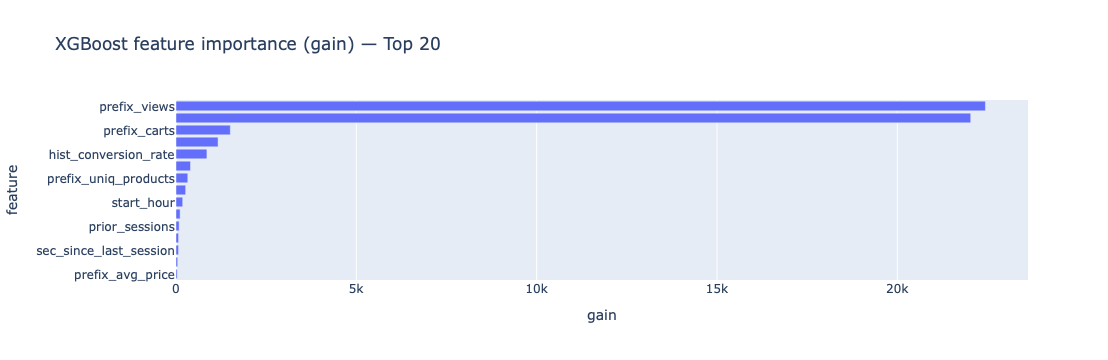

In [5]:
# Feature importance (XGBoost) — importance_type="gain"
booster = xgb_model.get_booster()
score_gain = booster.get_score(importance_type="gain")  # keys like "f0", "f1", ...

# Map f0..fN to your column names
feature_map = {f"f{i}": col for i, col in enumerate(feature_cols)}

imp = (
    pd.DataFrame(
        [
            {"feature": feature_map.get(k, k), "gain": v}
            for k, v in score_gain.items()
        ]
    )
    .sort_values("gain", ascending=False)
)

print("Top features by gain:")
print(imp.head(15))

fig_imp = px.bar(
    imp.head(20).iloc[::-1],  # reverse for nicer horizontal ordering
    x="gain",
    y="feature",
    orientation="h",
    title="XGBoost feature importance (gain) — Top 20",
)
fig_imp.show()

## Step 5/7 — Visual evaluation (ROC + Precision@K)

**What this does**: Plots ROC curves (overall ranking quality) and Precision@K (how good the top K predictions are).

**Why we do it**: With class imbalance, accuracy can look “good” even for weak models. ROC-AUC and Precision@K are usually more informative for purchase prediction.

**What to look for in the output**:
- ROC curve above the diagonal; higher AUC is better
- Precision@K is meaningfully above the baseline purchase rate

**Interpretation**:
- ROC-AUC: how well the model ranks purchasers above non-purchasers
- Precision@K: if you target the top K sessions, what fraction are true purchasers


Step 5/7: Visual evaluation (ROC + Precision@K)


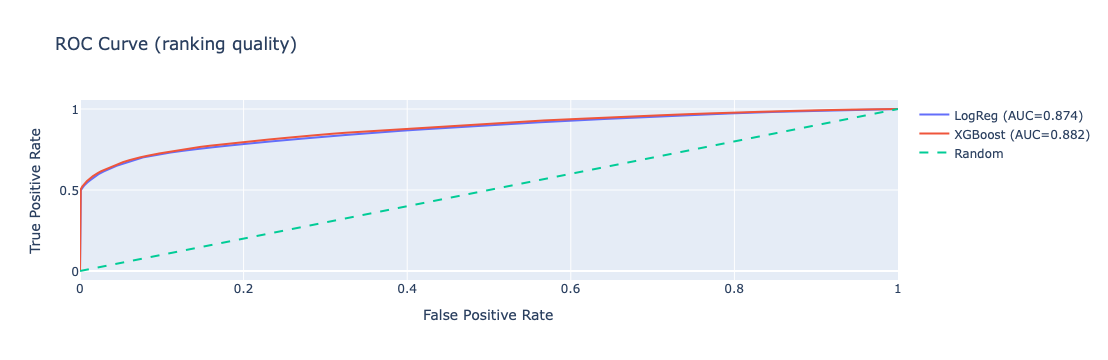

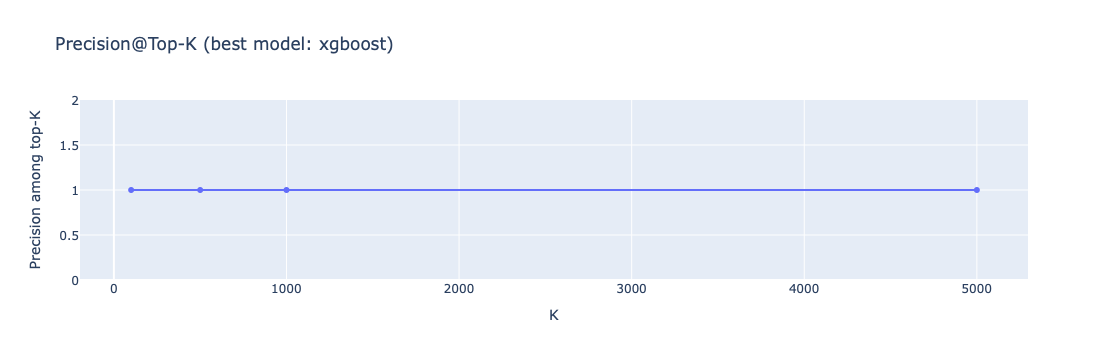

In [6]:
print("Step 5/7: Visual evaluation (ROC + Precision@K)")

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, p_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, p_xgb)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr_lr, y=tpr_lr, mode="lines", name=f"LogReg (AUC={metrics_lr['roc_auc']:.3f})"))
fig_roc.add_trace(go.Scatter(x=fpr_xgb, y=tpr_xgb, mode="lines", name=f"XGBoost (AUC={metrics_xgb['roc_auc']:.3f})"))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", name="Random", line=dict(dash="dash")))
fig_roc.update_layout(title="ROC Curve (ranking quality)", xaxis_title="False Positive Rate", yaxis_title="True Positive Rate")
fig_roc.show()

# Precision@K on best model
best_name, best_p = ("xgboost", p_xgb) if metrics_xgb["roc_auc"] >= metrics_lr["roc_auc"] else ("logreg", p_lr)
order = np.argsort(-best_p)
y_sorted = np.asarray(y_test)[order]

ks = [100, 500, 1000, 5000]
prec_at_k = [float(y_sorted[: min(k, len(y_sorted))].mean()) for k in ks]

fig_pk = px.line(x=ks, y=prec_at_k, markers=True, title=f"Precision@Top-K (best model: {best_name})")
fig_pk.update_layout(xaxis_title="K", yaxis_title="Precision among top-K")
fig_pk.show()


In [7]:
threshold_results = []

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_threshold = (best_p >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

best_threshold = threshold_df.sort_values("f1_score", ascending=False).iloc[0]["threshold"]
print("Selected threshold:", best_threshold)

final_predictions = (best_p >= best_threshold).astype(int)


,threshold,accuracy,precision,recall,f1_score
0,0.1,0.865491,0.489030,0.742612,0.589716
1,0.2,0.912115,0.659707,0.670954,0.665283
2,0.3,0.929028,0.798542,0.608233,0.690515
3,0.4,0.934454,0.898515,0.559681,0.689731
4,0.5,0.935314,0.957801,0.526261,0.679289
5,0.6,0.935091,0.978119,0.512838,0.672878
6,0.7,0.934325,0.991846,0.499587,0.664480
7,0.8,0.933302,0.999272,0.487977,0.655736
8,0.9,0.933060,1.000000,0.485762,0.653890


Selected threshold: 0.3


In [8]:
print(metrics_xgb)
print("Confusion matrix:\n", confusion_matrix(y_test, (p_xgb >= best_threshold).astype(int)))

print(metrics_lr)
print("Confusion matrix:\n", confusion_matrix(y_test, (p_lr >= best_threshold).astype(int)))

print("Model comparison:")
print(pd.DataFrame([metrics_lr, metrics_xgb]))

{'model': 'xgboost', 'roc_auc': 0.882310603469725, 'accuracy': 0.9353140064874165, 'precision': 0.9578008853253153, 'recall': 0.5262608416318664}
Confusion matrix:
 [[569065  13375]
 [ 34148  53016]]
{'model': 'logreg', 'roc_auc': 0.8738823237402218, 'accuracy': 0.9029993847109635, 'precision': 0.6143722194760257, 'recall': 0.6844339406176863}
Confusion matrix:
 [[410802 171638]
 [ 15050  72114]]
Model comparison:
     model   roc_auc  accuracy  precision    recall
0   logreg  0.873882  0.902999   0.614372  0.684434
1  xgboost  0.882311  0.935314   0.957801  0.526261


## Step 6/7 — Write predictions back to ClickHouse

**What this does**: Creates a table and inserts model scores (`p_purchase`) and a thresholded prediction (`pred_purchase`).

**Why we do it**: It closes the loop: ClickHouse becomes the system-of-record for both features and predictions, which makes it easy to power dashboards and downstream analysis.

**What to look for in the output**:
- Insert count > 0
- Top sessions by `p_purchase` look plausible

**Interpretation**: `p_purchase` is a *ranking score*; the 0.5 threshold is arbitrary—many real systems choose thresholds based on business constraints.


In [9]:
print("Step 6/7: Write predictions back to ClickHouse")

client.execute("DROP TABLE IF EXISTS session_purchase_predictions")
client.execute("""
    CREATE TABLE session_purchase_predictions
    (
      model_name String,
      user_session String,
      p_purchase Float32,
      pred_purchase UInt8
    )
    ENGINE = MergeTree
    ORDER BY (model_name, user_session)
    """)

test_sessions = df.loc[X_test.index, "user_session"].astype(str).to_numpy()

prediction_sets = [
    ("logreg", p_lr),
    ("xgboost", p_xgb),
]

all_data = []

for model_name, probs in prediction_sets:
    pred_labels = (probs >= 0.5).astype(int)

    all_data.extend(
        [
            (model_name, str(session), float(prob), int(pred))
            for session, prob, pred in zip(test_sessions, probs, pred_labels)
        ]
    )

client.execute(
    """
    INSERT INTO session_purchase_predictions
    (model_name, user_session, p_purchase, pred_purchase)
    VALUES
    """,
    all_data,
)

print_kv(
    "predictions inserted by model",
    client.execute("""
        SELECT model_name, count()
        FROM session_purchase_predictions
        GROUP BY model_name
        ORDER BY model_name
    """),
)

print("Top predicted purchase sessions:")
print(
    ch_df(
        client,
        """
    SELECT *
    FROM session_purchase_predictions
    ORDER BY p_purchase DESC
    LIMIT 10
    """,
        None,
    )
)

Step 6/7: Write predictions back to ClickHouse
predictions inserted by model: [('logreg', 669604), ('xgboost', 669604)]
Top predicted purchase sessions:
  model_name                          user_session  p_purchase  pred_purchase
0     logreg  0bc2c43e-8982-42e3-a4a3-1adc9e528582         1.0              1
1     logreg  0b39c37d-aa3d-4855-bc33-c7a91717b38b         1.0              1
2     logreg  0b49e2a9-66d5-436e-9f3c-6afa0b7577d2         1.0              1
3     logreg  0b59819e-4c13-47ce-94c5-24c15a0d1092         1.0              1
4     logreg  0b5993f2-1c14-4540-b2ef-5c864b367c80         1.0              1
5     logreg  0a91286c-8ee8-4dd7-a553-a2136f8cf36e         1.0              1
6     logreg  0b93f162-5dc1-4121-8610-3323feaf3039         1.0              1
7     logreg  0bb7ef43-8511-4c38-bbde-b6346d2ce2e2         1.0              1
8     logreg  0b852a59-7bd5-41b8-a642-27834a2579e9         1.0              1
9     logreg  0bb3ff8e-9bde-4603-9b12-781a7a534535         1.0     

## Step 7/7 — Inspectable test examples (3 per class)

**What this does**: Randomly samples **three test-set sessions with no purchase** and **three with a purchase** (fixed seed **42**) and prints the **same numeric features the model uses**, plus the **true label** and **model scores**.

**Why we do it**: Metrics summarize the whole test set; concrete rows make the pipeline tangible for demos and grading.

**Important**: Rows are drawn only from **`X_test` / `y_test`** (held-out data), not training data.

**Note**: `pred_purchase` uses **`best_threshold`** from Step 5 (F1-selected), not a hard-coded 0.5.

In [10]:
print("Step 7/7: Inspectable test examples (stratified random sample, seed=42)")

rng = np.random.RandomState(42)
n_per_class = 3

demo = X_test.copy().reset_index(drop=True)
demo.insert(0, "user_session", df.loc[X_test.index, "user_session"].astype(str).to_numpy())
demo["has_purchase_in_session"] = y_test.to_numpy()
demo["p_purchase"] = np.asarray(best_p, dtype=float)
demo["pred_purchase"] = (demo["p_purchase"] >= float(best_threshold)).astype(int)

out_cols = ["user_session"] + feature_cols + [
    "has_purchase_in_session",
    "p_purchase",
    "pred_purchase",
]

idx0 = np.flatnonzero(demo["has_purchase_in_session"].to_numpy() == 0)
idx1 = np.flatnonzero(demo["has_purchase_in_session"].to_numpy() == 1)

k0 = min(n_per_class, len(idx0))
k1 = min(n_per_class, len(idx1))
if k0 == 0 or k1 == 0:
    raise ValueError("y_test must contain both classes (0 and 1) for stratified demo sampling.")

pick0 = rng.choice(idx0, size=k0, replace=False)
pick1 = rng.choice(idx1, size=k1, replace=False)
pick = np.sort(np.concatenate([pick0, pick1]))

print_kv("Demo model", best_name)
print_kv("Demo threshold (pred_purchase)", float(best_threshold))
print()
print("Random test examples — 3 non-purchase (0) and 3 purchase (1):")
display(demo.loc[pick, out_cols])

Step 7/7: Inspectable test examples (stratified random sample, seed=42)
Demo model: xgboost
Demo threshold (pred_purchase): 0.3

Random test examples — 3 non-purchase (0) and 3 purchase (1):


,user_session,start_hour,time_to_eventN_sec,prefix_events,prefix_views,prefix_carts,prefix_purchases,prefix_uniq_products,prefix_uniq_categories,prefix_uniq_brands,prefix_avg_price,prefix_max_price,prefix_cart_value_sum,prior_sessions,prior_purchase_count,sec_since_last_session,hist_conversion_rate,has_purchase_in_session,p_purchase,pred_purchase
130056,e03841a5-8be4-4f8b-968c-987c2623c8c3,3,48,5,5,0,0,3,1,2,455.013989,531.409973,0.000000,1,1,384,1.0,1,0.333841,1
165674,81181112-938a-4ee5-b6d4-9e93a3429a2b,8,292,5,5,0,0,3,1,1,100.077998,103.989998,0.000000,1,0,1303403,0.0,0,0.072725,0
205428,91587f2a-e947-471b-a7ad-0ba08a1143c5,15,417,5,5,0,0,4,1,3,930.256006,1422.890015,0.000000,17,0,7585,0.0,0,0.016603,0
425435,165a4137-0dd0-4f1f-9b90-e45d597de915,9,148,5,4,1,0,2,1,1,250.666003,250.690002,250.660004,6,0,33,0.0,1,0.207303,0
564350,4e37f462-b535-423d-8e7a-7a02c402af46,6,864,5,5,0,0,3,1,1,16.912000,22.879999,0.000000,20,2,314754,0.1,0,0.110341,0
614799,295e59e9-f2de-48ea-b14c-73e59983c140,14,73,5,3,2,0,2,1,2,369.846008,389.920013,779.840027,0,0,1571495649,0.0,1,0.435940,1
